In [1]:
import pandas as pd

In [3]:
data = pd.read_csv('top20_countries.csv')
data

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population
0,Afghanistan,58.1,652230,323000,2.1,19101353833,47.9,64.5,38041754,48.9,11.12,9797273
1,Albania,43.1,28748,9000,28.1,15278077447,7.8,78.5,2854191,55.7,12.33,1747593
2,Algeria,17.4,2381741,317000,0.8,169988236398,20.1,76.7,43053054,41.2,11.70,31510100
3,Angola,47.5,1246700,117000,46.3,94635415870,51.6,60.8,31825295,77.5,6.89,21061025
4,Argentina,54.3,2780400,105000,9.8,449663446954,8.8,76.5,44938712,61.3,9.79,41339571
5,Armenia,58.9,29743,49000,11.7,13672802158,11.0,74.9,2957731,55.6,16.99,1869848
6,Australia,48.2,7741220,58000,16.3,1392680589329,3.1,82.7,25766605,65.5,5.27,21844756
7,Austria,32.4,83871,21000,46.9,446314739528,2.9,81.6,8877067,60.7,4.67,5194416
8,Azerbaijan,57.7,86600,82000,14.1,39207000000,19.2,72.9,10023318,66.5,5.51,5616165
9,The Bahamas,1.4,13880,1000,51.4,12827000000,8.3,73.8,389482,74.6,10.36,323784


In [9]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

In [6]:
numerical_data = data.select_dtypes(include=[float, int])

In [8]:
mds = MDS(n_components=2, random_state=42)
mds_transformed = mds.fit_transform(numerical_data)

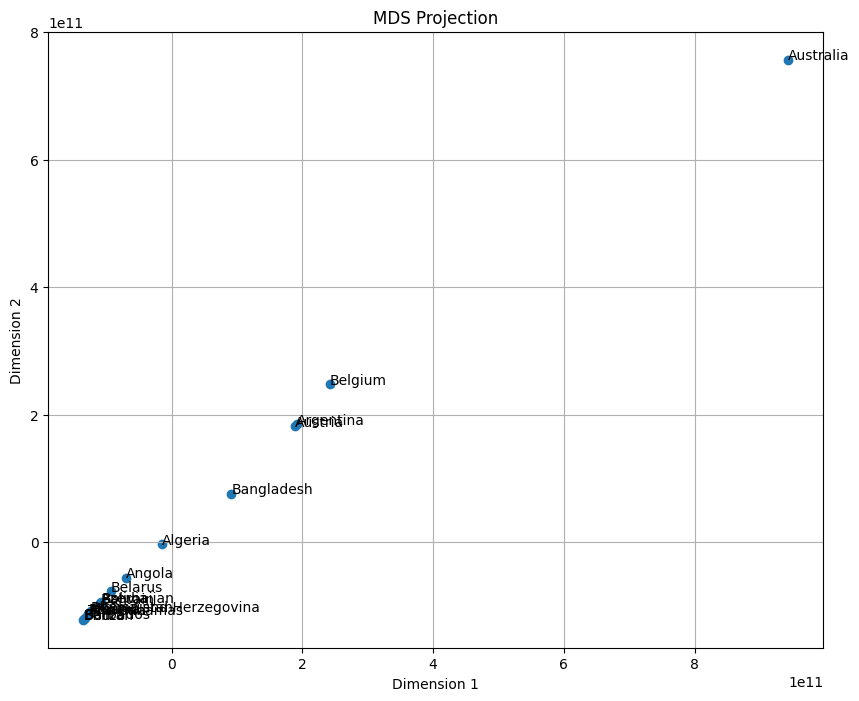

In [11]:
mds_df = pd.DataFrame(mds_transformed, columns=['Dimension 1', 'Dimension 2'])

plt.figure(figsize=(10, 8))
plt.scatter(mds_df['Dimension 1'], mds_df['Dimension 2'])

for i, country in enumerate(data['Country']):
    plt.text(mds_df.loc[i, 'Dimension 1'], mds_df.loc[i, 'Dimension 2'], country)

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('MDS Projection')
plt.grid(True)
plt.show()

In [19]:
from sklearn.datasets import load_iris
from sklearn.metrics import pairwise_distances

In [13]:
iris = load_iris()
data = iris.data
labels = iris.target
feature_names = iris.feature_names

In [14]:
df = pd.DataFrame(data, columns=feature_names)

In [18]:
mds = MDS(n_components=2, random_state=42, dissimilarity='euclidean')
mds_transformed = mds.fit_transform(df)

In [20]:
original_distances = pairwise_distances(data)
low_dim_distances = pairwise_distances(mds_transformed)

stress = ((original_distances - low_dim_distances) ** 2).sum() / (original_distances ** 2).sum()
stress = stress ** 0.5

print(f'Stress 값: {stress:.4f}')

Stress 값: 0.0405


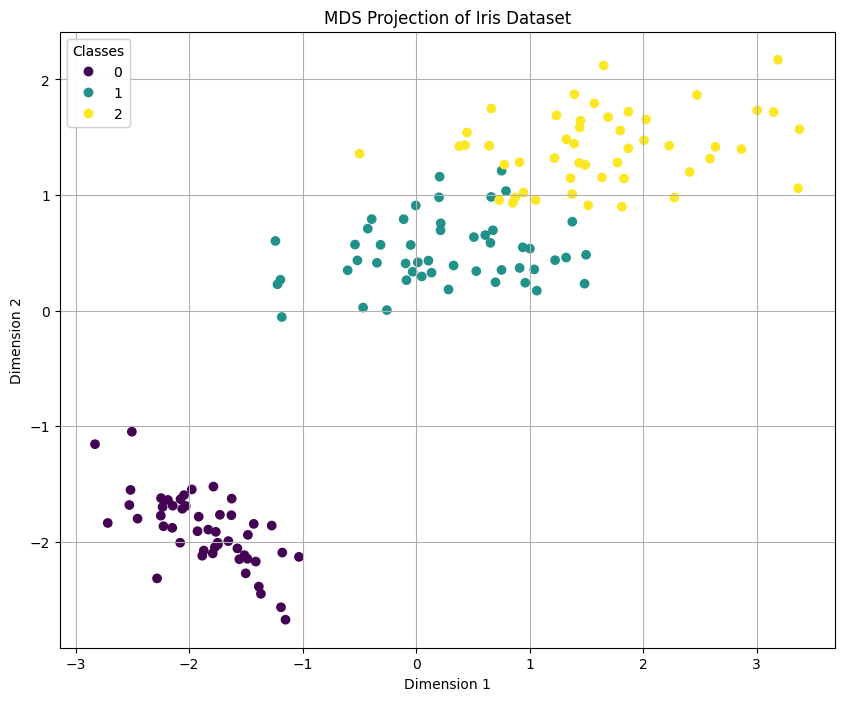

In [16]:
mds_df = pd.DataFrame(mds_transformed, columns=['Dimension 1', 'Dimension 2'])
mds_df['label'] = labels

plt.figure(figsize=(10, 8))
scatter = plt.scatter(mds_df['Dimension 1'], mds_df['Dimension 2'], c=mds_df['label'], cmap='viridis')

legend = plt.legend(*scatter.legend_elements(), title="Classes")
plt.gca().add_artist(legend)

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('MDS Projection of Iris Dataset')
plt.grid(True)
plt.show()